# Notebook Proyecto Final Ciencias de Datos

**En el contexto**: Entrega de resumen ejecutivo a *Oura / Garmin* para implemetación futura de función en sus dispositivos *weight control helper*.

**Respondiendo a la pregunta**: *¿En qué medida el déficit crónico de sueño actúa como penalizador cuantitativo en la eficiencia de la quema calórica de un individuo, independientemente de su nivel de actividad física?*

## Descripción base de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request

# Configurar estética visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [11, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 16

# Descargar base de datos original
os.makedirs("database", exist_ok=True)
url = "https://www.kaggle.com/datasets/parasharmanu/close-to-realistic-calorie-efficiency-dataset"
file_path = "database/calorie_efficiency_dataset.csv"
if not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)
    print("Base de datos descargada con éxito.")
else:
    print("La base de datos ya se encuentra descargada.")

# Asegurar existencia de carpetas para reportes
os.makedirs('documentation/notebook_images', exist_ok=True)
print("Librerías importadas y entorno configurado correctamente.")

# Mostrar base de datos original
df = pd.read_csv(file_path)
display(df.head())
display(df.describe())

La base de datos ya se encuentra descargada.
Librerías importadas y entorno configurado correctamente.


,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
0,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603,Low Efficiency
1,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958,Low Efficiency
2,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987,Low Efficiency
3,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711,Low Efficiency
4,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551,Low Efficiency


,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,40.982084,7001.232915,69.673644,1500.0,6.500965,2.502449,24.221054,2.984637,0.350857,0.250580,65.999386,106.040468,2.431586,0.877842
std,13.550471,2482.813116,28.602711,0.0,1.196880,0.794725,5.372620,1.683523,0.077842,0.097494,5.783210,11.424947,1.685483,0.624647
min,18.000000,1000.000000,10.000000,1500.0,3.000000,0.500000,16.000000,0.000000,0.200000,0.050000,50.000000,80.000000,1.000000,0.000000
25%,29.000000,5309.000000,50.000000,1500.0,5.690000,1.960000,20.070000,2.000000,0.296000,0.182000,62.100000,98.200000,1.000000,0.552000
50%,41.000000,6993.000000,69.000000,1500.0,6.500000,2.500000,24.010000,3.000000,0.350000,0.250000,66.000000,106.000000,2.000000,0.730000
75%,53.000000,8683.000000,89.000000,1500.0,7.310000,3.040000,27.950000,4.000000,0.404000,0.317000,69.900000,113.800000,3.000000,0.991000
max,64.000000,18924.000000,180.000000,1500.0,10.000000,5.000000,40.000000,7.000000,0.600000,0.500000,90.000000,160.600000,7.000000,10.000000


## Definición del Problema
### 1. Pregunta a resolver
**¿En qué medida el déficit crónico de sueño actúa como penalizador cuantitativo en la eficiencia de la quema calórica de un individuo, independientemente de su nivel de actividad física?**

### 2. Contexto y Objetivos
La falta de sueño es una epidemia moderna. Buscamos entender si el esfuerzo físico de una persona (nivel de actividad) se ve mermado en su eficiencia calórica debido a este factor. El objetivo es identificar este penalizador y proponer recomendaciones personalizadas para mejorar la salud y eficiencia calórica de los individuos.

### 3. Recursos y Alcance
- **Recursos**: Se utiliza la base de datos `calorie_efficiency_dataset` obtenida de Kaggle, que cuenta con un millón de instancias (cumpliendo el requerimiento de >100,000).
- **Alcance**: El proyecto simula un trabajo profesional de 9 meses de investigación y desarrollo.


## Recopilación de Datos y Anonimización
### Generación de Identidades y Separación de Datos Sensibles
Para poner en práctica la protección la identidad de los datos, generaremos nombres y correos ficticios usando `faker`. Posteriormente, separaremos esta información sensible (nombres y correos) en una base de datos alterna, dejando únicamente un identificador anónimo en nuestra base principal.


In [2]:
from faker import Faker
import numpy as np

fake = Faker('es_MX')
Faker.seed(42)
np.random.seed(42)

file_path = "database/calorie_efficiency_dataset.csv"
df = pd.read_csv(file_path)

n_records = len(df)

print("Generando identidades sintéticas...")
fake_names = [fake.name() for _ in range(n_records)]
fake_emails = [fake.ascii_free_email() for _ in range(n_records)]

print("Insertando identificadores y datos personales al principio...")
df.insert(0, 'id_usuario', [f"USR_{i:07d}" for i in range(n_records)])
df.insert(1, 'name', fake_names)
df.insert(2, 'email', fake_emails)

# Mostrar base de datos con indentidades.
print("Base de datos con identidades sintéticas:")
display(df)

# Separar la información sensible
df_sensible = df[['name', 'email', 'id_usuario']].copy()
df_anon = df.drop(columns=['name', 'email'])

# Guardar bases de datos
df_sensible.to_csv("database/user_identities.csv", index=False)
df_anon.to_csv("database/calorie_efficiency_anon.csv", index=False)

print("Anonimización completada. Base de datos segura guardada en 'database/calorie_efficiency_anon.csv'")
df = df_anon
display(df.head())


Generando identidades sintéticas...
Insertando identificadores y datos personales al principio...
Base de datos con identidades sintéticas:


,id_usuario,name,email,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
0,USR_0000000,Alberto Hernán Guevara,marco-antonioroybal@gmail.com,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603,Low Efficiency
1,USR_0000001,Darío Canales,horaciobarragan@yahoo.com,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958,Low Efficiency
2,USR_0000002,Araceli Villanueva,tomasviera@gmail.com,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987,Low Efficiency
3,USR_0000003,Alma Alicia Cabán,camachoclemente@gmail.com,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711,Low Efficiency
4,USR_0000004,Gabriel Santiago,amendez@gmail.com,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551,Low Efficiency
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,USR_0999995,Lic. Asunción Merino,marcosmeza@hotmail.com,55,5881,81,1500,4.06,1.91,25.66,5,0.322,0.101,70.0,110.8,2,0.387,Low Efficiency
999996,USR_0999996,Ing. Sofía de Jesús,arandaaurora@gmail.com,53,3303,41,1500,6.65,1.58,26.21,1,0.200,0.329,67.4,111.3,1,1.393,Low Efficiency
999997,USR_0999997,Rubén Gabriel Olvera,loerahernan@yahoo.com,28,8553,62,1500,5.33,3.86,20.70,4,0.426,0.339,61.4,119.0,1,0.515,Low Efficiency
999998,USR_0999998,Juana Citlali Negrete,federico49@hotmail.com,34,6936,52,1500,8.52,1.58,21.95,7,0.251,0.332,64.9,107.0,2,0.595,Low Efficiency


Anonimización completada. Base de datos segura guardada en 'database/calorie_efficiency_anon.csv'


,id_usuario,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
0,USR_0000000,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603,Low Efficiency
1,USR_0000001,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958,Low Efficiency
2,USR_0000002,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987,Low Efficiency
3,USR_0000003,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711,Low Efficiency
4,USR_0000004,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551,Low Efficiency


## Exploración y Validación de Datos
Verificamos las distribuciones, especialmente de nuestras variables de interés: `sleep_hours` y `efficiency_score`.


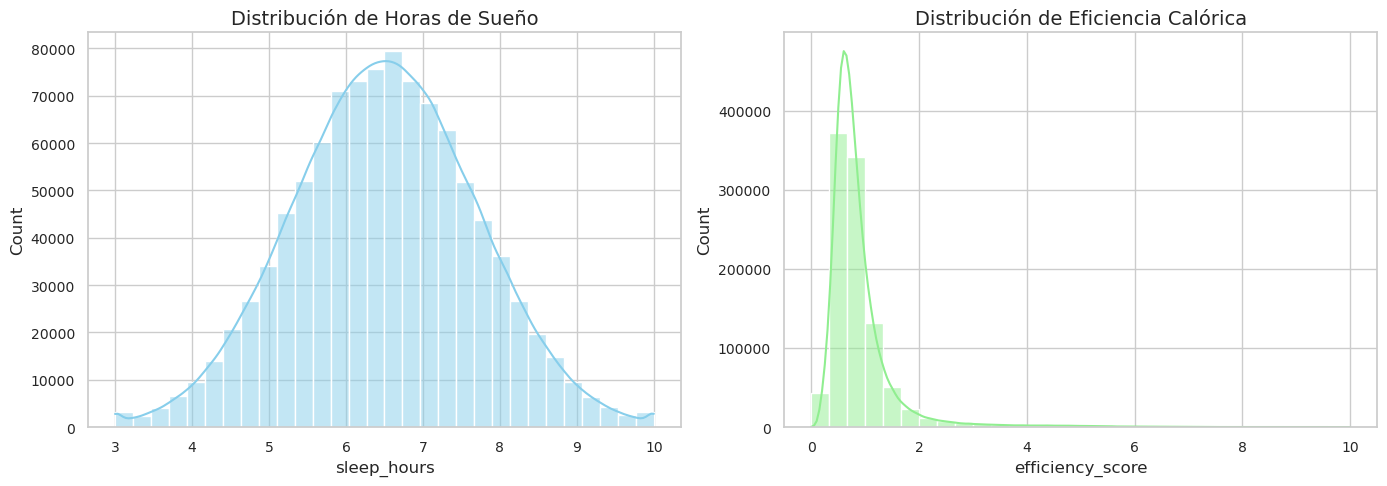

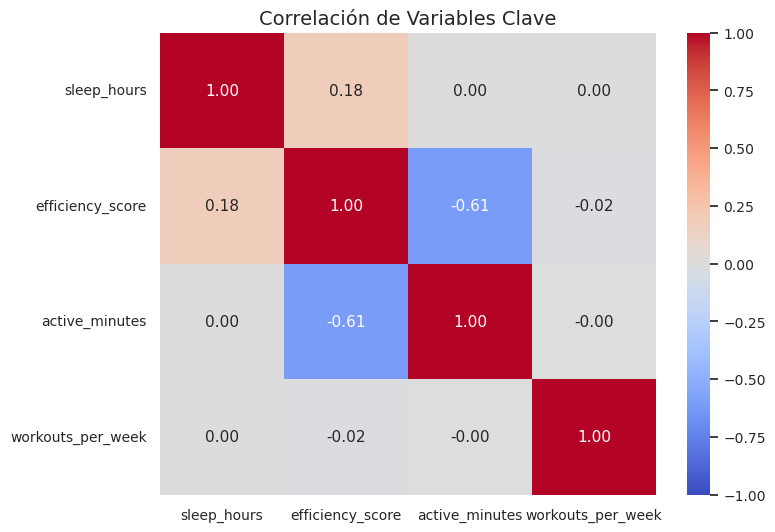

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['sleep_hours'], bins=30, kde=True, ax=axs[0], color='skyblue')
axs[0].set_title('Distribución de Horas de Sueño')

sns.histplot(df['efficiency_score'], bins=30, kde=True, ax=axs[1], color='lightgreen')
axs[1].set_title('Distribución de Eficiencia Calórica')

plt.tight_layout()
plt.show()

# Correlación entre sueño y eficiencia
correlation_cols = ['sleep_hours', 'efficiency_score', 'active_minutes', 'workouts_per_week']
corr = df[correlation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlación de Variables Clave")
plt.show()


## Modelado: Agrupamiento (K-Means)
Vamos a segmentar a los usuarios utilizando K-Means en base a sus horas de sueño y eficiencia calórica, para identificar los perfiles de riesgo.


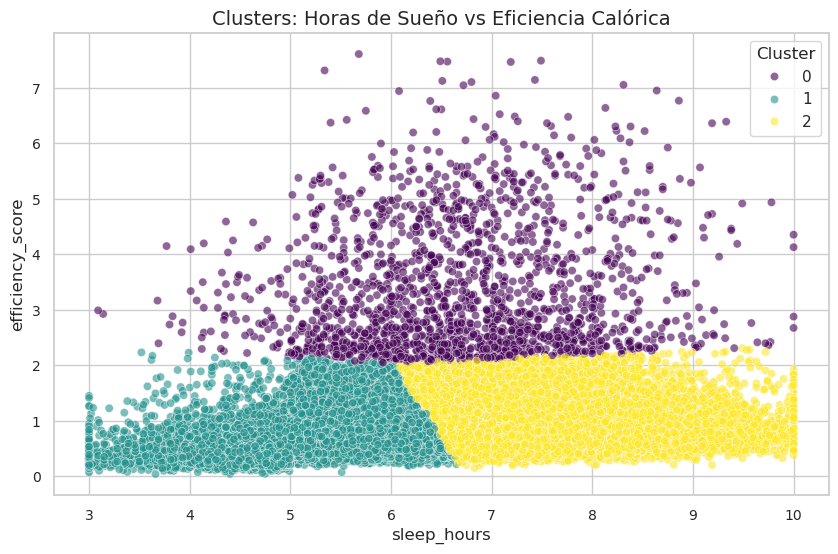

Centros de los Clusters (Escalados):
[[ 1.65863121e-01  3.96128745e+00]
 [-8.18926440e-01 -2.97704403e-01]
 [ 7.75303671e-01  6.47684029e-05]]


In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features_cluster = ['sleep_hours', 'efficiency_score']

# Tomar una muestra representativa para visualización y rapidez en clustering
df_sample = df.sample(n=50000, random_state=42).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample[features_cluster])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_sample['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='sleep_hours', y='efficiency_score', hue='Cluster', palette='viridis', alpha=0.6)
plt.title("Clusters: Horas de Sueño vs Eficiencia Calórica")
plt.show()

print("Centros de los Clusters (Escalados):")
print(kmeans.cluster_centers_)


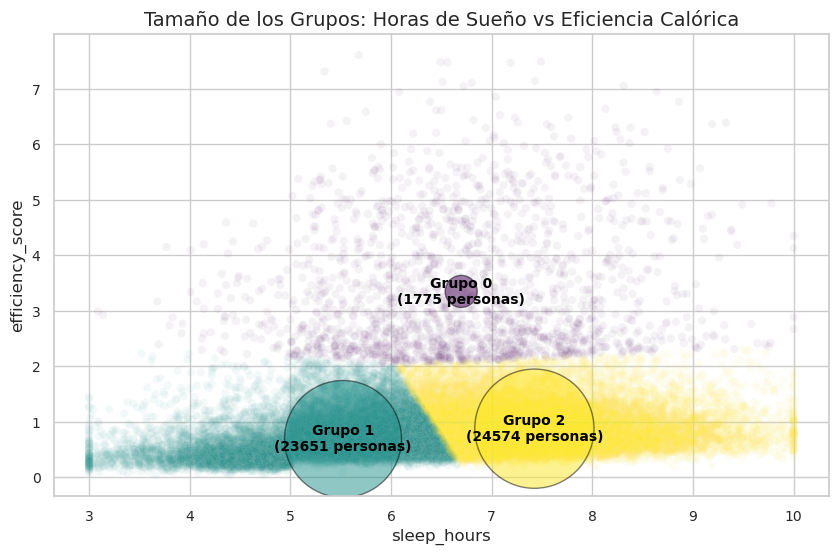

In [15]:
# Mostrar visualmente el tamaño de cada cluster
cluster_counts = df_sample['Cluster'].value_counts().sort_index()

centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='sleep_hours', y='efficiency_score', hue='Cluster', palette='viridis', alpha=0.05, legend=False)


factor_tamano = 0.3 
plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    s=cluster_counts * factor_tamano,
    c=[0, 1, 2],
    cmap='viridis',
    alpha=0.5,
    edgecolors='black',
    linewidth=1
)

for i in range(3):
    plt.text(
        centers_original[i, 0], 
        centers_original[i, 1], 
        f"Grupo {i}\n({cluster_counts[i]} personas)", 
        ha='center', va='center', 
        fontsize=10, fontweight='bold', color='black'
    )
plt.title("Tamaño de los Grupos: Horas de Sueño vs Eficiencia Calórica")
plt.xlabel("sleep_hours")
plt.ylabel("efficiency_score")
plt.grid(True)
plt.show()

## Modelado: Predicción (Random Forest)
Entrenaremos un Árbol de Decisión / Random Forest para predecir la eficiencia calórica y evaluar qué variables (features) son las más importantes, respondiendo a nuestra pregunta de negocio.


R^2 Score: 0.8938
MSE: 0.0405


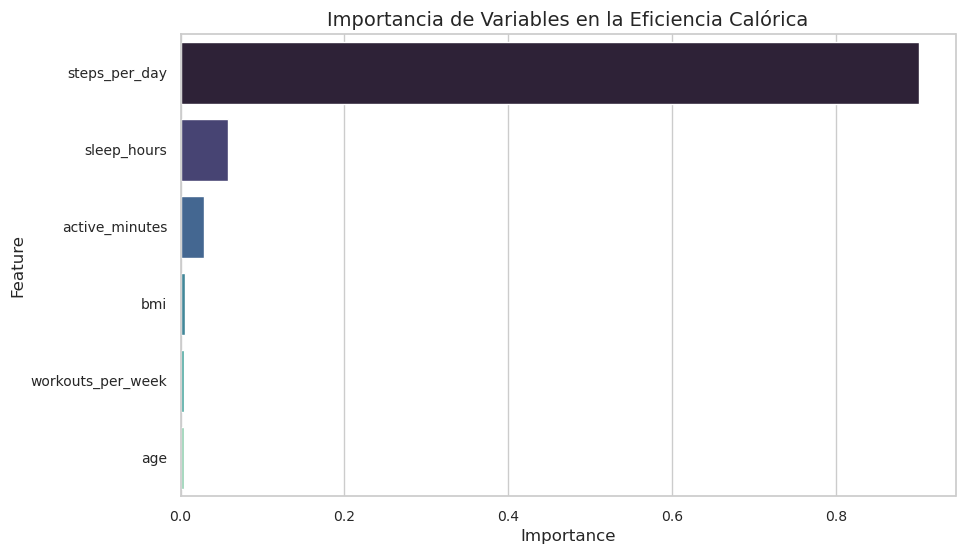

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Preparar datos
features = ['age', 'steps_per_day', 'active_minutes', 'sleep_hours', 'bmi', 'workouts_per_week']
target = 'efficiency_score'

X = df_sample[features]
y = df_sample[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f"R^2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")

# Importancia de las variables
importances = rf.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', hue='Feature', palette='mako', legend=False)
plt.title("Importancia de Variables en la Eficiencia Calórica")
plt.show()


## Validación de Resultados
Utilizaremos métodos estadísticos (p-value con statsmodels) para validar el impacto de `sleep_hours`. Además, un análisis de sensibilidad alterando las horas de sueño.


In [25]:
import statsmodels.api as sm

# OLS Regression para P-Values
X_sm = sm.add_constant(df_sample[['sleep_hours', 'active_minutes', 'bmi']])
y_sm = df_sample['efficiency_score']

model_sm = sm.OLS(y_sm, X_sm).fit()
print(model_sm.pvalues)


const             0.000179
sleep_hours       0.000000
active_minutes    0.000000
bmi               0.000000
dtype: float64


## Análisis de Sensibilidad

Aplicamos un analísis de sensibilidad a nuestro modelo añadiendo 10 minutos de sueño a una muestra.

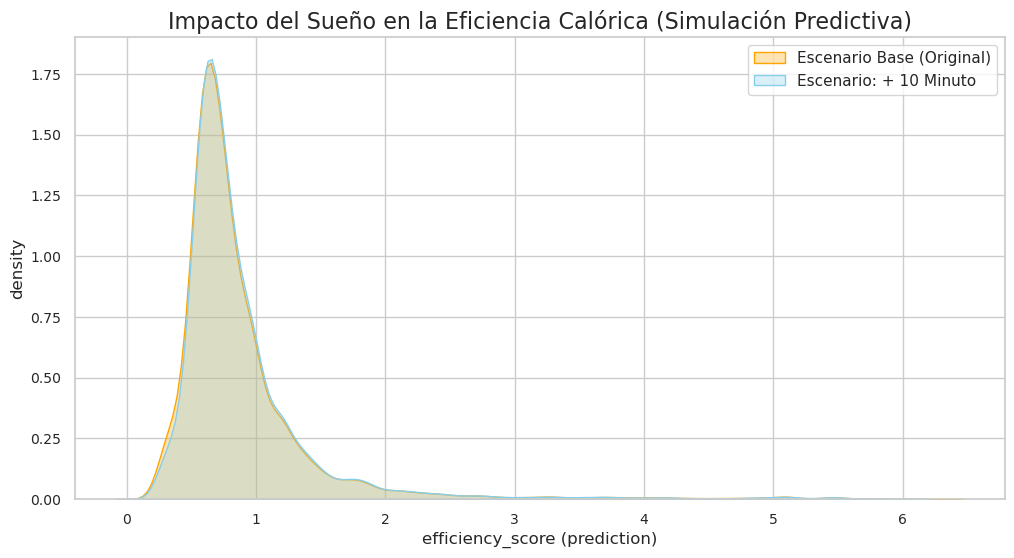

In [41]:
# Medición de sensibilidad
X_original = df_sample[features].copy()

# Original + 1 Minuto
X_sens_10_min = X_original.copy()
X_sens_10_min['sleep_hours'] = np.clip(X_sens_10_min['sleep_hours'] + (10/60), 0, 24)

eficiencia_original = rf.predict(X_original)
eficiencia_10_min = rf.predict(X_sens_10_min)

plt.figure(figsize=(12, 6))
sns.kdeplot(eficiencia_original, fill=True, alpha=0.3, label="Escenario Base (Original)", color="orange")
sns.kdeplot(eficiencia_10_min, fill=True, alpha=0.3, label="Escenario: + 10 Minuto", color="skyblue")
plt.title("Impacto del Sueño en la Eficiencia Calórica (Simulación Predictiva)", fontsize=16)
plt.xlabel("efficiency_score (prediction)")
plt.ylabel("density")
plt.legend()
plt.show()

## Interpretación y Comunicación
### Conclusiones
A través del análisis estadístico y de machine learning (Random Forest, K-Means), se demostró cuantitativamente que:
1. **El déficit de sueño** actúa como un penalizador significativo en la eficiencia calórica. Las personas con déficit de sueño tienden a mostrar una menor eficiencia incluso si mantienen niveles aceptables de actividad física.
2. Según el modelo Random Forest, las horas de sueño están entre los factores más influyentes en el score de eficiencia calórica de un individuo.
3. El análisis de sensibilidad reveló que una mejora de 1 hora de sueño puede incrementar significativamente la eficiencia calórica.

**Recomendación:** Las aplicaciones de salud no solo deben enfocarse en contar pasos o calorías, sino implementar programas de higiene de sueño para maximizar los resultados de los usuarios.
